# Combined spike / LFP analysis — stage 2

**Objective.** Now that we have the spike data processed and the PCA scores over the full time window we can compare the spikining activity with the narrow band components of the ~150 Hz high-frequency oscillation (HFO) from the LFP,
. We ask whether the dominant LFP mode moves together with the dominant spiking mode — before and after the ketamine
injection.

**Prerequisite.** This notebook requires the cache written by
`spike_data_pca.ipynb` (`../data/spike_pca.npz`). The Gaussian smoothing and the
spike PCA are *not* recomputed here; only the analog signals are loaded.

**Pipeline**

1. Load the cached spike rates / PCA and the raw LFP.
2. Wavelet transform at the HFO frequency → amplitude envelope per electrode.
3. PCA on the envelope → spatial LFP modes.
4. Raw signal → envelope → components, for one example channel.
5. Correlate PC1(spikes) with PC1(LFP envelope).
6. Map the LFP loadings back onto the electrode array.
7. Redo the correlation separately before and after the injection.


## 0. Imports and configuration

Imports and paths.

- **elephant** provides `signal_processing.wavelet_transform`, used to isolate the
  HFO band.
- `../source/utils.py` supplies the shared style, the ketamine marker, the scree
  plot, `zscore`, and the two colours (`SPIKE_COLOR`, `LFP_COLOR`) that keep the
  two modalities visually distinct across every figure.

`SPIKE_PCA_FILE` must already exist — it is written by `spike_data_pca.ipynb`.
`POSITIONS_FILE` maps channel ids to their physical position on the probe and is
used in section 6.

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt
import quantities as pq
import elephant
from neo.io import NixIO
from sklearn.decomposition import PCA

sys.path.insert(0, "../source")
from utils import (LFP_COLOR, SPIKE_COLOR, mark_event, plot_scree, use_analysis_style,
                   zscore)

NIX_FILE = "../data/rat_retreat_meta_1kHz.nix"
POSITIONS_FILE = "../data/channel_positions.pkl"
SPIKE_PCA_FILE = "../data/spike_pca.npz"    # written by spike_data_pca.py

# Draw the figures inline in the interactive window. Same effect as the
# `%matplotlib inline` magic, but plain Python, so the editor does not flag it.
plt.switch_backend("module://matplotlib_inline.backend_inline")
use_analysis_style()

## 1. Load the cached spike results and the raw LFP

Load both modalities into a common frame of reference.

From the cache: the smoothed rates, the spike PCA (scores, loadings, explained
variance), the unit labels, and the session scalars — so the injection time and
the recording length are guaranteed to match stage 1.

From the NIX file: the raw analog signals, `(n_time, n_channels)`, at 1 kHz. The
printout is the place to check that the LFP and the cached rates really are on the
same sampling grid before anything is correlated.

In [2]:
spike_pca = np.load(SPIKE_PCA_FILE)

times_rate = spike_pca["times"]                 # seconds
rates = spike_pca["rates"]                      # (n_time, n_neurons), Hz
scores_spike = spike_pca["scores"]              # (n_time, n_pc)
loadings_spike = spike_pca["loadings"]
ratio_spike = spike_pca["ratio"]
unit_labels = list(spike_pca["unit_labels"])
ketamine_time = float(spike_pca["ketamine_time"]) * pq.s
recording_duration = float(spike_pca["recording_duration"]) * pq.s
kernel_sigma_ms = float(spike_pca["kernel_sigma_ms"])

with NixIO(NIX_FILE, mode="ro") as io:
    block = io.read_block()

seg = block.segments[0]
signals = seg.analogsignals[0]              # (n_time, n_channels)
n_channels = signals.shape[1]
fs = signals.sampling_rate
times_lfp = signals.times.rescale("s").magnitude

print(f"cached spikes: rates {rates.shape}, scores {scores_spike.shape}, "
      f"Gaussian sigma = {kernel_sigma_ms:.0f} ms")
print(f"LFP: {signals.shape[0]} samples x {n_channels} channels at {fs}")
print(f"recording: {recording_duration}, ketamine at {ketamine_time}")

cached spikes: rates (705000, 13), scores (705000, 13), Gaussian sigma = 100 ms
LFP: 705000 samples x 64 channels at 1000.0 Hz
recording: 705.0 s, ketamine at 372.0 s


## 2. Wavelet transform at the HFO frequency

Isolate the oscillation of interest.

A complex Morlet wavelet centred on 150 Hz — the frequency of the post-ketamine
HFO — is convolved with every channel. The complex output splits into two useful
signals:

- **real part** → the band-filtered, still-oscillating signal (what a bandpass
  filter would give);
- **modulus** → the amplitude envelope, i.e. *how strong* the 150 Hz oscillation
  is at each moment, with the fast oscillation itself removed.

The envelope is the quantity that can be compared with a 100 ms-smoothed firing
rate; the raw oscillation could not.

In [3]:
HFO_FREQUENCY = 150 * pq.Hz     # centre frequency of the post-ketamine HFO

signals_wavelets = elephant.signal_processing.wavelet_transform(
    signals, frequency=[HFO_FREQUENCY], sampling_frequency=fs)

wavelet_signals = signals_wavelets.squeeze()    # complex, (n_time, n_electrodes)
real_signals = wavelet_signals.real             # band-filtered (oscillating) signal
envelope_signals = np.abs(wavelet_signals)      # HFO amplitude envelope
print(f"wavelet output: {envelope_signals.shape} (n_time, n_electrodes)")

wavelet output: (705000, 64) (n_time, n_electrodes)


## 3. PCA on the HFO envelope across electrodes

Reduce the 64-channel envelope to a few spatial modes, exactly as the spikes were
reduced in stage 1: samples are time bins, features are electrodes.

Each component is therefore a **spatial pattern over the probe** with a time
course. Because neighbouring electrodes see largely the same field, the first
component usually absorbs most of the variance — the scree plot quantifies that.

The bar panels show the electrode weights of the two leading components; their
physical layout is recovered in section 6.

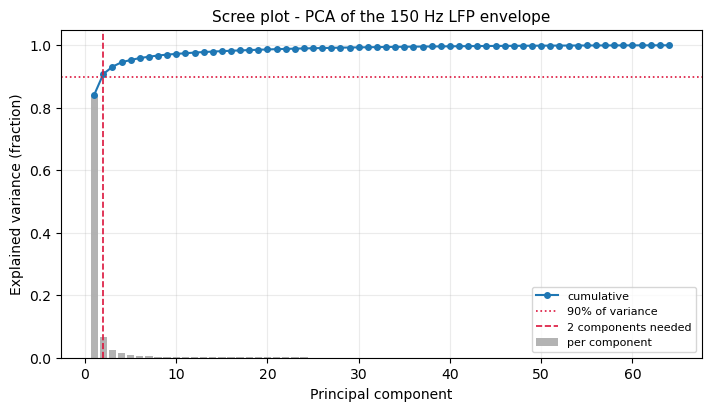

LFP: 2 components explain >90% of the variance
[0.841 0.908 0.931 0.946 0.953 0.959 0.963 0.967 0.97  0.972]


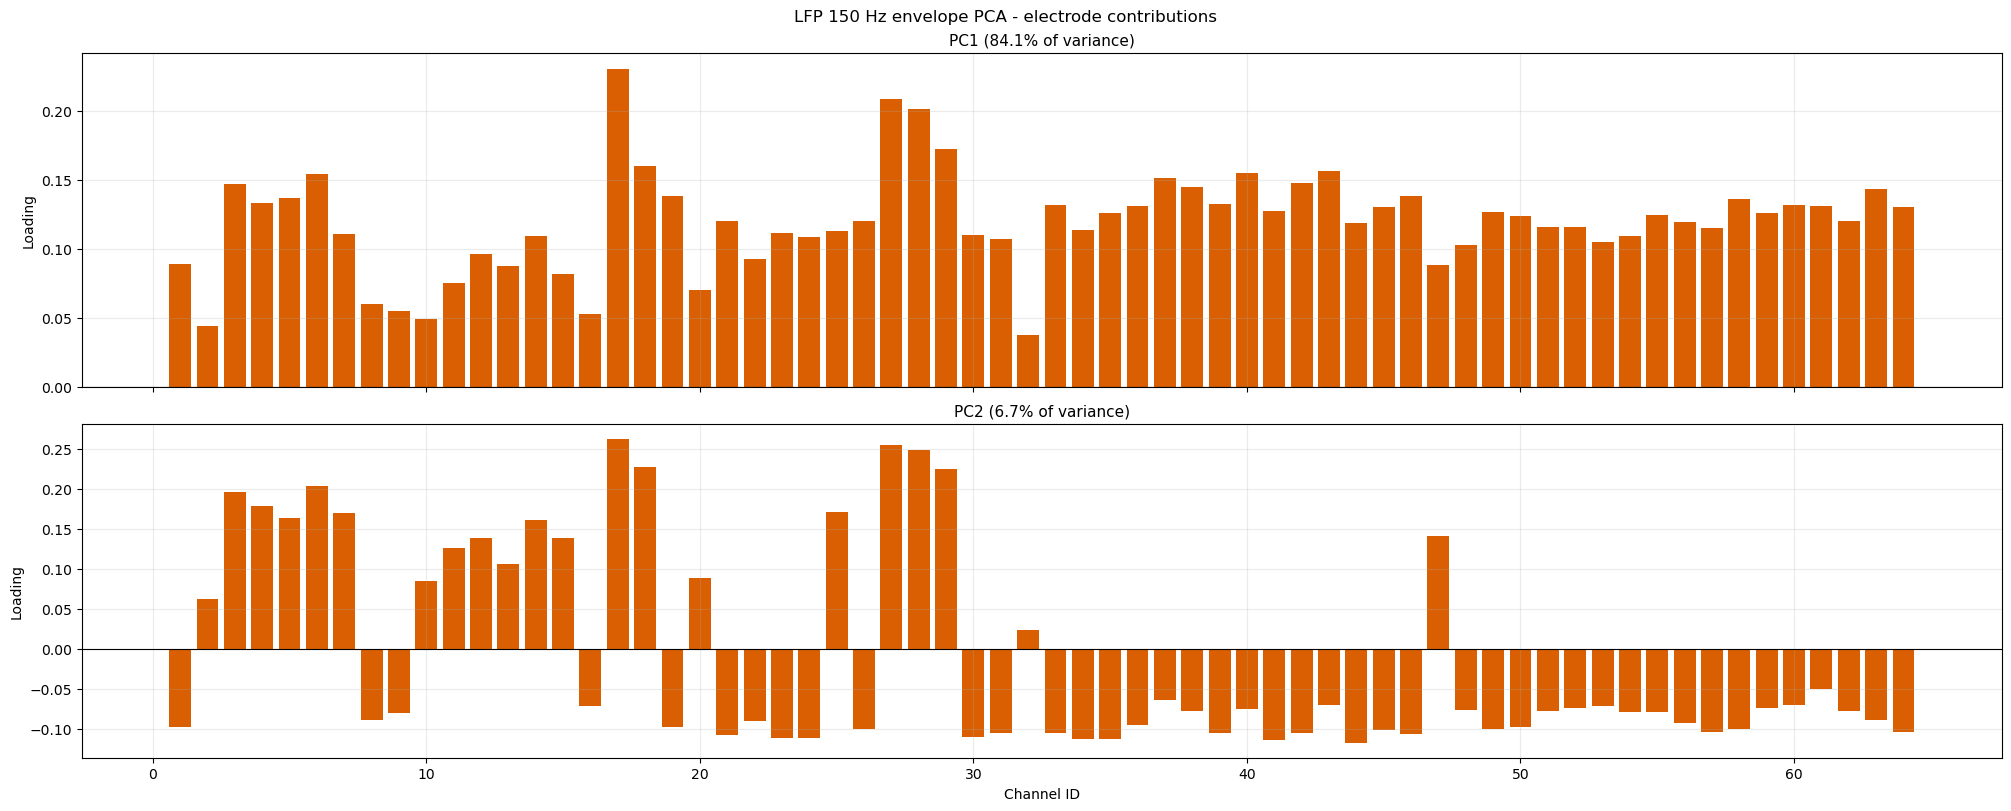

In [4]:
VARIANCE_THRESHOLD = 0.9    # cumulative variance target reported on the scree plot

pca_lfp = PCA()
scores_lfp = pca_lfp.fit_transform(np.asarray(envelope_signals))  # (n_time, n_ch)
loadings_lfp = pca_lfp.components_                                # (n_pc, n_ch)
ratio_lfp = pca_lfp.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 4))
cum_lfp, n_pc_lfp = plot_scree(
    ratio_lfp, f"Scree plot - PCA of the {HFO_FREQUENCY.item():.0f} Hz LFP envelope",
    ax, threshold=VARIANCE_THRESHOLD)
plt.show()

print(f"LFP: {n_pc_lfp} components explain >{VARIANCE_THRESHOLD:.0%} of the variance")
print(np.round(cum_lfp[:10], 3))

# Electrode contributions to the two leading components.
fig, axes = plt.subplots(2, 1, figsize=(20, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.bar(np.arange(1, n_channels + 1), loadings_lfp[i], color=LFP_COLOR)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylabel("Loading")
    ax.set_title(f"PC{i + 1} ({ratio_lfp[i]:.1%} of variance)")
axes[-1].set_xlabel("Channel ID")
fig.suptitle(f"LFP {HFO_FREQUENCY.item():.0f} Hz envelope PCA - "
             f"electrode contributions")
plt.show()

We observe that the variance of the 150hz activity is caputerd by only a few Pricipal components (2). The first PC is a wieghed positive sum of all elecrodes meaning they covary linearly in the same direction and produce most of the activity. 


## 4. From raw LFP to population components - one example channel process

A single figure showing the whole signal chain before preforming PCA on a 2 s window straddling the
injection, so each transformation can be checked against the one above it:

1. raw LFP of the example channel,
2. the same signal filtered at 150 Hz (real part of the wavelet),
3. its amplitude envelope,
4. the LFP envelope PC1 — now pooling *all* electrodes,
5. and 6. the leading spike PCs over the same window.

`np.searchsorted` on the time axes is used instead of `int(t * fs)`: the LFP and
the rates carry different sampling-rate units (Hz vs 1/ms), which quietly breaks
index arithmetic but not a search on the actual time values.

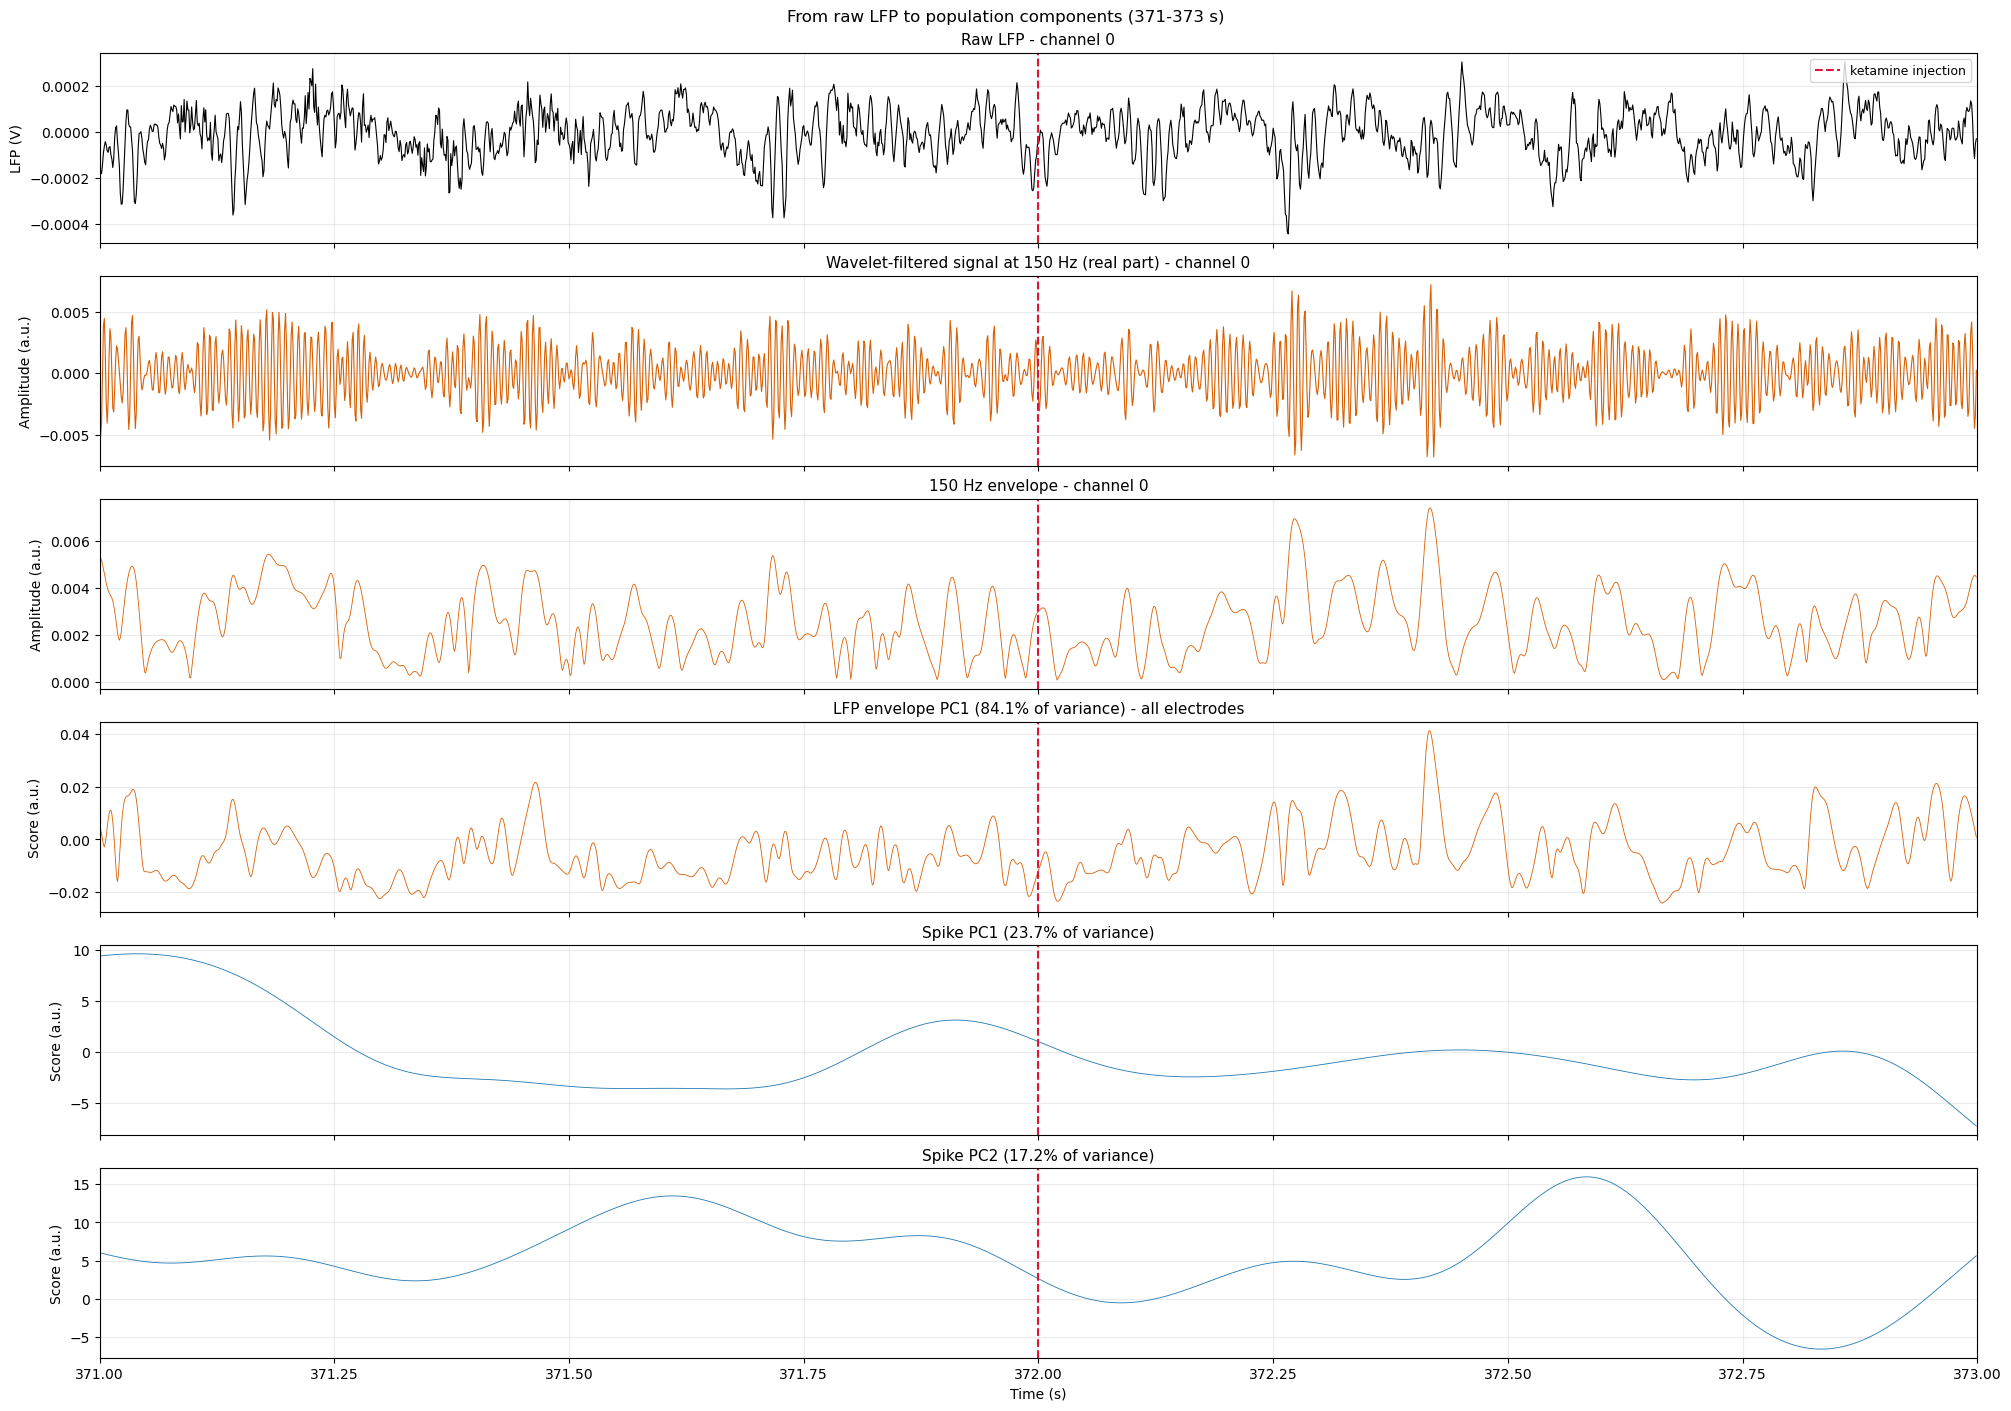

In [6]:
CHANNEL = 0                                     # electrode to display
T_START, T_STOP = 371 * pq.s, 373 * pq.s        # tight window around the injection

# searchsorted on the time axes: robust to the LFP and the rates carrying
# different sampling-rate units (Hz vs 1/ms), which quietly breaks int(t * fs).
lfp_win = slice(*np.searchsorted(times_lfp, [float(T_START), float(T_STOP)]))
rate_win = slice(*np.searchsorted(times_rate, [float(T_START), float(T_STOP)]))

fig, axes = plt.subplots(6, 1, figsize=(20, 14), sharex=True)

axes[0].plot(times_lfp[lfp_win], signals[lfp_win, CHANNEL].magnitude, lw=0.8, color="k")
axes[0].set_ylabel(f"LFP ({signals.units.dimensionality})")
axes[0].set_title(f"Raw LFP - channel {CHANNEL}")

axes[1].plot(times_lfp[lfp_win], real_signals[lfp_win, CHANNEL], lw=0.8, color=LFP_COLOR)
axes[1].set_ylabel("Amplitude (a.u.)")
axes[1].set_title(f"Wavelet-filtered signal at {HFO_FREQUENCY.item():.0f} Hz "
                  f"(real part) - channel {CHANNEL}")

axes[2].plot(times_lfp[lfp_win], envelope_signals[lfp_win, CHANNEL], lw=0.6,
             color=LFP_COLOR)
axes[2].set_ylabel("Amplitude (a.u.)")
axes[2].set_title(f"{HFO_FREQUENCY.item():.0f} Hz envelope - channel {CHANNEL}")

axes[3].plot(times_lfp[lfp_win], scores_lfp[lfp_win, 0], lw=0.6, color=LFP_COLOR)
axes[3].set_ylabel("Score (a.u.)")
axes[3].set_title(f"LFP envelope PC1 ({ratio_lfp[0]:.1%} of variance) - all electrodes")

for row, pc in zip((4, 5), (0, 1)):
    axes[row].plot(times_rate[rate_win], scores_spike[rate_win, pc], lw=0.6,
                   color=SPIKE_COLOR)
    axes[row].set_ylabel("Score (a.u.)")
    axes[row].set_title(f"Spike PC{pc + 1} ({ratio_spike[pc]:.1%} of variance)")

for ax in axes:
    mark_event(ax, ketamine_time)
    ax.set_xlim(float(T_START), float(T_STOP))
axes[0].legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"From raw LFP to population components "
             f"({float(T_START):.0f}-{float(T_STOP):.0f} s)")
plt.show()

## 5. Correlation between the spiking mode and the HFO mode

The central question of the notebook: does the dominant spiking mode track the
dominant HFO mode?

Both score series are truncated to their common length and z-scored — Pearson *r*
is invariant to that rescaling, so the normalisation exists purely so the two
traces can share one y-axis.

The reported *r* covers the whole recording; the plot zooms to the minute before
the injection onwards, which is where the coupling is expected to appear.

spike scores (705000, 13), LFP scores (705000, 64)
corr(PC1 spikes, PC1 LFP envelope) = 0.455


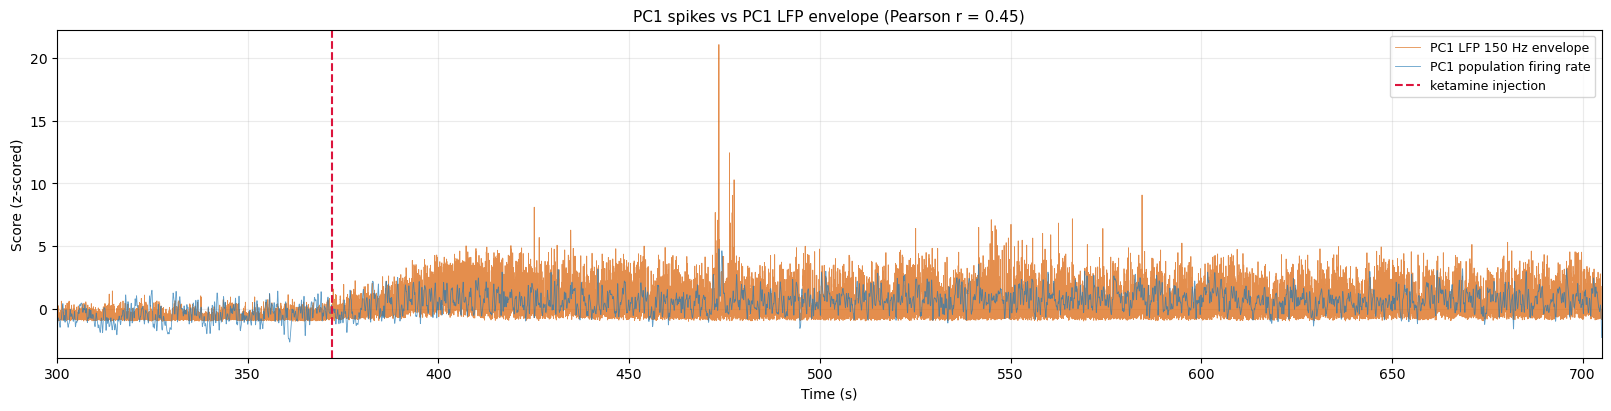

In [7]:
# Pearson r is invariant to z-scoring; the normalisation is only there so both
# traces can be drawn on one axis.
n_common = min(scores_spike.shape[0], scores_lfp.shape[0])
scores_spike_norm = zscore(scores_spike[:n_common])
scores_lfp_norm = zscore(scores_lfp[:n_common])

r_pc1 = np.corrcoef(scores_spike_norm[:, 0], scores_lfp_norm[:, 0])[0, 1]
print(f"spike scores {scores_spike.shape}, LFP scores {scores_lfp.shape}")
print(f"corr(PC1 spikes, PC1 LFP envelope) = {r_pc1:.3f}")

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(times_rate[:n_common], scores_lfp_norm[:, 0], lw=0.6, alpha=0.7,
        color=LFP_COLOR, label=f"PC1 LFP {HFO_FREQUENCY.item():.0f} Hz envelope")
ax.plot(times_rate[:n_common], scores_spike_norm[:, 0], lw=0.6, alpha=0.7,
        color=SPIKE_COLOR, label="PC1 population firing rate")
mark_event(ax, ketamine_time)
ax.set_xlim(float(ketamine_time) - 72, float(recording_duration))
ax.set_xlabel("Time (s)")
ax.set_ylabel("Score (z-scored)")
ax.set_title(f"PC1 spikes vs PC1 LFP envelope (Pearson r = {r_pc1:.2f})")
ax.legend(fontsize=9)
plt.show()

## 6. Map the LFP loadings back onto the electrode array

Put the LFP components back into anatomical space.

`channel_positions.pkl` maps each channel id (1–64) to `(x = shank,
y = position from tip)`, so the loading vector of a component can be reshaped onto
the physical probe grid. Missing sites stay `NaN`.

A component whose loadings are uniform in sign means the whole array sees the same
oscillation; a component that flips sign across shanks or along depth points at a
spatial gradient or a source/sink boundary.

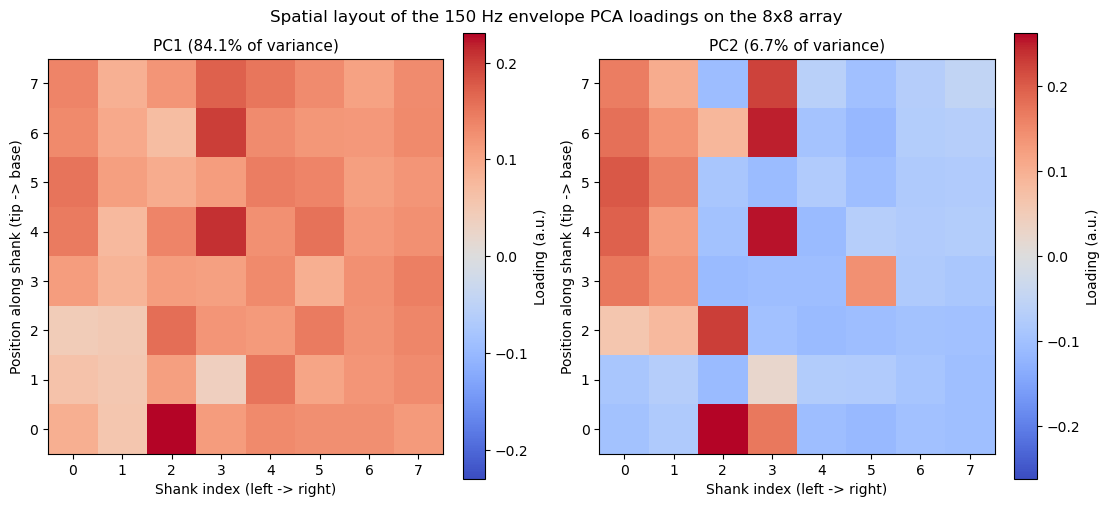

In [8]:
# channel_positions.pkl: {channel_id (1-64): (x = shank, y = position from tip)}
electrode_mapping = np.load(POSITIONS_FILE, allow_pickle=True)
positions = np.array(list(electrode_mapping.values()))
n_rows, n_cols = positions[:, 1].max() + 1, positions[:, 0].max() + 1

COMPONENTS_TO_MAP = (0, 1)      # LFP components to draw on the array


def loadings_to_array(component):
    """Arrange the loadings of one LFP component on the probe grid."""
    grid = np.full((n_rows, n_cols), np.nan)
    for channel_id, (x, y) in electrode_mapping.items():
        grid[y, x] = loadings_lfp[component, channel_id - 1]
    return grid


fig, axes = plt.subplots(1, len(COMPONENTS_TO_MAP), figsize=(11, 5))
for ax, component in zip(np.atleast_1d(axes), COMPONENTS_TO_MAP):
    grid = loadings_to_array(component)
    vmax = np.nanmax(np.abs(grid))
    mesh = ax.pcolormesh(grid, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(n_cols) + 0.5, labels=np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows) + 0.5, labels=np.arange(n_rows))
    ax.grid(False)
    ax.set_xlabel("Shank index (left -> right)")
    ax.set_ylabel("Position along shank (tip -> base)")
    ax.set_title(f"PC{component + 1} ({ratio_lfp[component]:.1%} of variance)")
    fig.colorbar(mesh, ax=ax, label="Loading (a.u.)")
fig.suptitle(f"Spatial layout of the {HFO_FREQUENCY.item():.0f} Hz envelope PCA "
             f"loadings on the {n_rows}x{n_cols} array")
plt.show()

<img src="brain.png" width="500">

## 7. Spike / LFP coupling split at the injection

Split the recording at the injection and recompute the coupling in each epoch.

The components themselves are the ones fitted on the **whole** recording (as in
section 5), so both epochs are read in a common basis and their correlations are
directly comparable. Only the time axis is split here. Because the basis is
shared, the *sign* of *r* is comparable across epochs too: a flip from before to
after is a real change in the relationship, whereas the overall sign of any single
PC stays arbitrary.

The rates are smoothed with a 100 ms Gaussian, so samples straddling the injection
are mixtures of both epochs; `EPOCH_GUARD` drops a 1 s band around it (set it to 0
to keep every sample).

`coupling_matrix` returns Pearson *r* between every spike PC and every LFP PC as an
`(n_pc, n_pc)` matrix — rows are spike components, columns are LFP components.
Correlating the two blocks together and reading off the off-diagonal quadrant is
equivalent to looping over the pairs.

**No p-values are reported on purpose:** consecutive samples of a 100 ms-smoothed
signal are nowhere near independent, so the nominal *n* of ~370,000 would make any
test meaningless.

The two figures are the time courses per epoch, and the full spike-PC × LFP-PC
matrices on a shared −1…1 scale so the panels can be compared cell by cell.

before ketamine: 371000 samples (0.0 - 371.0 s)
after ketamine: 331999 samples (373.0 - 705.0 s)

before ketamine - rows = spike PCs, columns = LFP PCs
[[ 0.128 -0.008 -0.014]
 [ 0.099  0.004 -0.02 ]
 [-0.034 -0.008 -0.006]]

after ketamine - rows = spike PCs, columns = LFP PCs
[[ 0.154  0.015 -0.003]
 [-0.012 -0.013  0.008]
 [-0.093  0.016  0.004]]

PC1 vs PC1: before = +0.128, after = +0.154 (whole recording = +0.455)


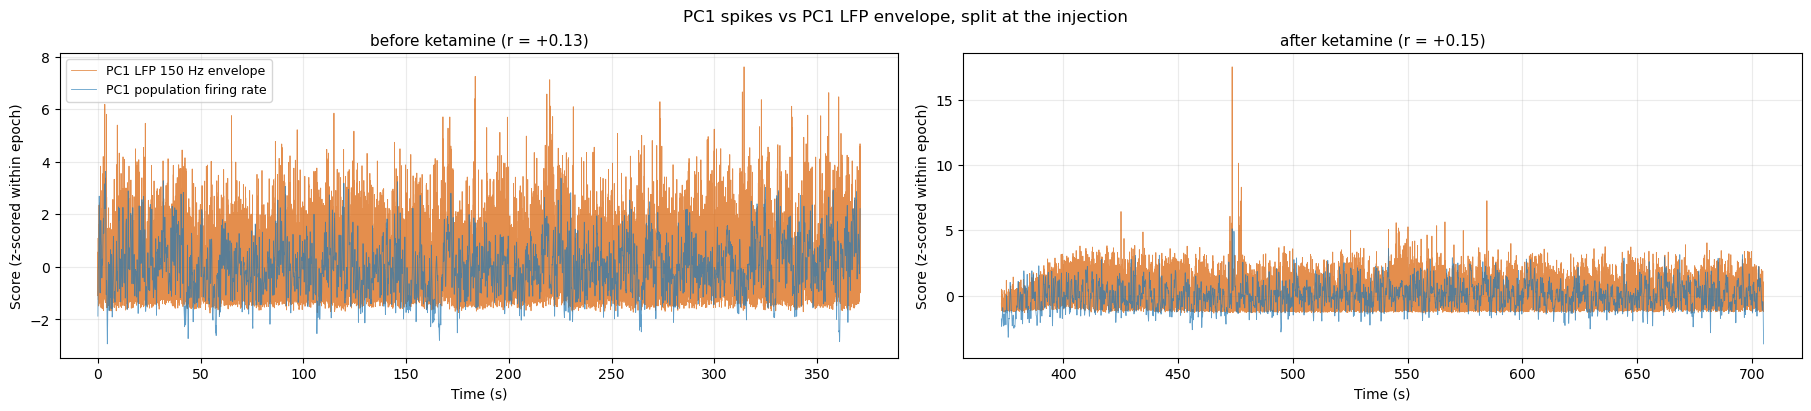

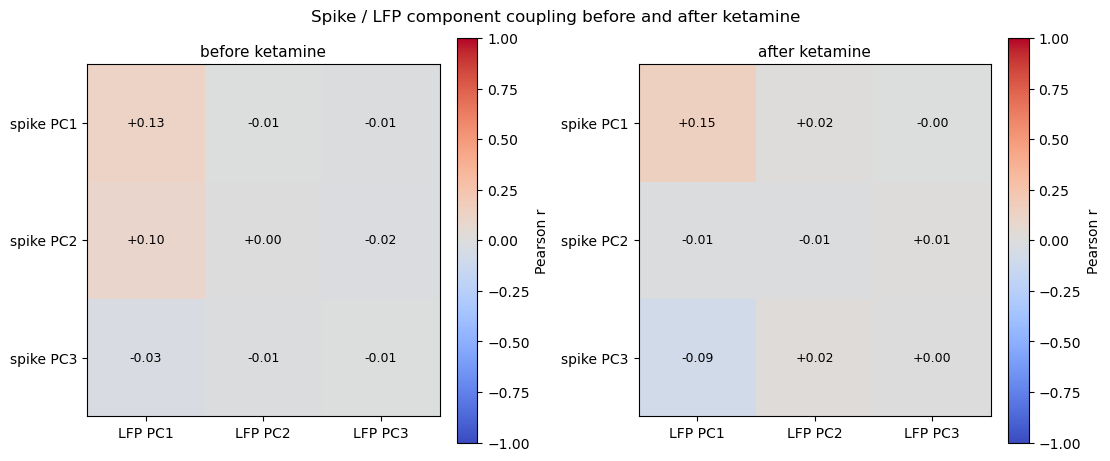

In [9]:
# The components themselves are the ones fitted on the whole recording (as in
# section 5), so both epochs are read in a common basis and their correlations
# are directly comparable. Only the time axis is split here.
#
# Because the basis is shared, the *sign* of r is comparable across epochs too:
# a flip from before to after is a real change in the relationship, whereas the
# overall sign of any single PC stays arbitrary.
#
# The rates are smoothed with a 100 ms Gaussian, so samples straddling the
# injection are mixtures of both epochs; EPOCH_GUARD drops a short band around
# it. Set it to 0 to keep every sample.
N_PCS_COUPLING = 3          # leading components entering the correlation matrix
EPOCH_GUARD = 1 * pq.s      # excluded either side of the injection

times_common = times_rate[:n_common]
epochs = {
    "before ketamine": times_common < float(ketamine_time) - float(EPOCH_GUARD),
    "after ketamine": times_common > float(ketamine_time) + float(EPOCH_GUARD),
}

for name, mask in epochs.items():
    print(f"{name}: {mask.sum()} samples "
          f"({times_common[mask][0]:.1f} - {times_common[mask][-1]:.1f} s)")


def coupling_matrix(mask, n_pc=N_PCS_COUPLING):
    """Pearson r between every spike PC and every LFP PC inside `mask`.

    Returns an (n_pc, n_pc) matrix: rows are spike components, columns are LFP
    components. Correlating the two blocks together and reading off the
    off-diagonal quadrant is equivalent to looping over the pairs.
    """
    both = np.corrcoef(scores_spike[:n_common, :n_pc][mask],
                       scores_lfp[:n_common, :n_pc][mask], rowvar=False)
    return both[:n_pc, n_pc:]


matrices = {name: coupling_matrix(mask) for name, mask in epochs.items()}

# No p-values: consecutive samples of a 100 ms-smoothed signal are nowhere near
# independent, so the nominal n of ~370,000 would make any test meaningless.
for name, r in matrices.items():
    print(f"\n{name} - rows = spike PCs, columns = LFP PCs")
    print(np.round(r, 3))
print(f"\nPC1 vs PC1: before = {matrices['before ketamine'][0, 0]:+.3f}, "
      f"after = {matrices['after ketamine'][0, 0]:+.3f} "
      f"(whole recording = {r_pc1:+.3f})")

# Time course of the two PC1s in each epoch. Z-scored within the epoch so both
# traces stay legible; Pearson r is unaffected by that rescaling.
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
for ax, (name, mask) in zip(axes, epochs.items()):
    ax.plot(times_common[mask], zscore(scores_lfp[:n_common, 0][mask]),
            lw=0.6, alpha=0.7, color=LFP_COLOR,
            label=f"PC1 LFP {HFO_FREQUENCY.item():.0f} Hz envelope")
    ax.plot(times_common[mask], zscore(scores_spike[:n_common, 0][mask]),
            lw=0.6, alpha=0.7, color=SPIKE_COLOR, label="PC1 population firing rate")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Score (z-scored within epoch)")
    ax.set_title(f"{name} (r = {matrices[name][0, 0]:+.2f})")
axes[0].legend(fontsize=9)
fig.suptitle("PC1 spikes vs PC1 LFP envelope, split at the injection")
plt.show()

# Full spike-PC x LFP-PC correlation matrix for each epoch, on a shared -1..1
# scale so the two panels can be compared cell by cell.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, r) in zip(axes, matrices.items()):
    mesh = ax.pcolormesh(r, cmap="coolwarm", vmin=-1, vmax=1)
    for i in range(N_PCS_COUPLING):
        for j in range(N_PCS_COUPLING):
            ax.text(j + 0.5, i + 0.5, f"{r[i, j]:+.2f}", ha="center", va="center",
                    fontsize=9)
    ax.set_aspect("equal")
    ax.invert_yaxis()       # PC1 at the top, like the printed matrix
    ax.set_xticks(np.arange(N_PCS_COUPLING) + 0.5,
                  labels=[f"LFP PC{i + 1}" for i in range(N_PCS_COUPLING)])
    ax.set_yticks(np.arange(N_PCS_COUPLING) + 0.5,
                  labels=[f"spike PC{i + 1}" for i in range(N_PCS_COUPLING)])
    ax.grid(False)
    ax.set_title(name)
    fig.colorbar(mesh, ax=ax, label="Pearson r")
fig.suptitle("Spike / LFP component coupling before and after ketamine")
plt.show()